In [1]:
'''
Ausreißer Entfernung
'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
import datetime
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans

def remove_outliers(data, n_clusters=1, distance_threshold=10):
    print('data size before outlier removal: ', len(data))
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(data)
    cluster_centers = kmeans.cluster_centers_
    print('single cluster for outlier removal: ', cluster_centers)

    distances = cdist(data, cluster_centers, 'euclidean')
    min_distances = np.min(distances, axis=1)
    is_outlier = min_distances > distance_threshold
    print('Number of outliers: ', np.sum(is_outlier))
    
    filtered_data = data[~is_outlier]
    return filtered_data

prices = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Tariffmodelle\TG\2024_data_grouped_Industrie.csv', index_col=[0])

summer_series = prices[prices['group'] == 'summer']['Wholesale price corrected']
winter_series = prices[prices['group'] == 'winter']['Wholesale price corrected']

summer = np.array(summer_series).reshape(-1, 1)
winter = np.array(winter_series).reshape(-1, 1)

summer_clean = remove_outliers(summer)
winter_clean = remove_outliers(winter)

data size before outlier removal:  5136
single cluster for outlier removal:  [[14.45971144]]
Number of outliers:  183
data size before outlier removal:  3648
single cluster for outlier removal:  [[15.62388137]]
Number of outliers:  100


C:\Users\fu\AppData\Local\anaconda3\envs\tariff_gen\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Das System kann die angegebene Datei nicht finden
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\fu\AppData\Local\anaconda3\envs\tariff_gen\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\fu\AppData\Local\anaconda3\envs\tariff_gen\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\fu\AppData\Local\anaconda3\envs\tariff_gen\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File

summer 3-Stufen:  [[18.76710647]
 [14.54237866]
 [ 7.87405518]]


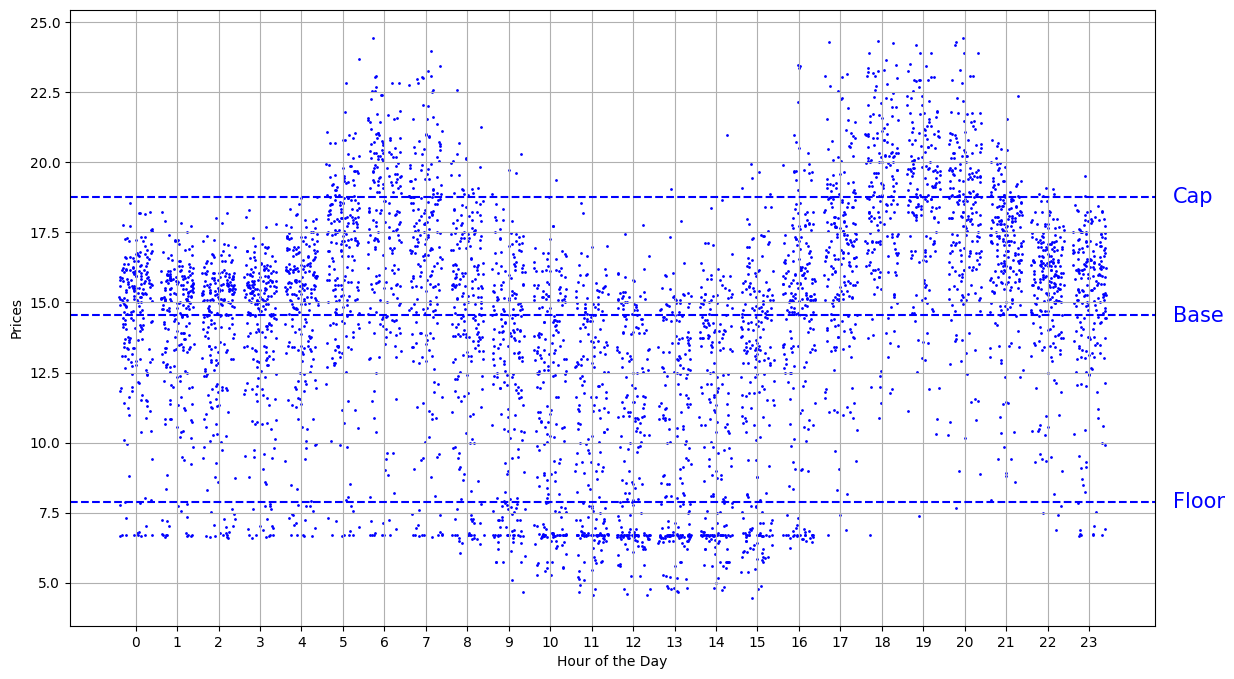

winter 3-Stufen:  [[19.05144964]
 [14.01611949]
 [ 8.7660935 ]]


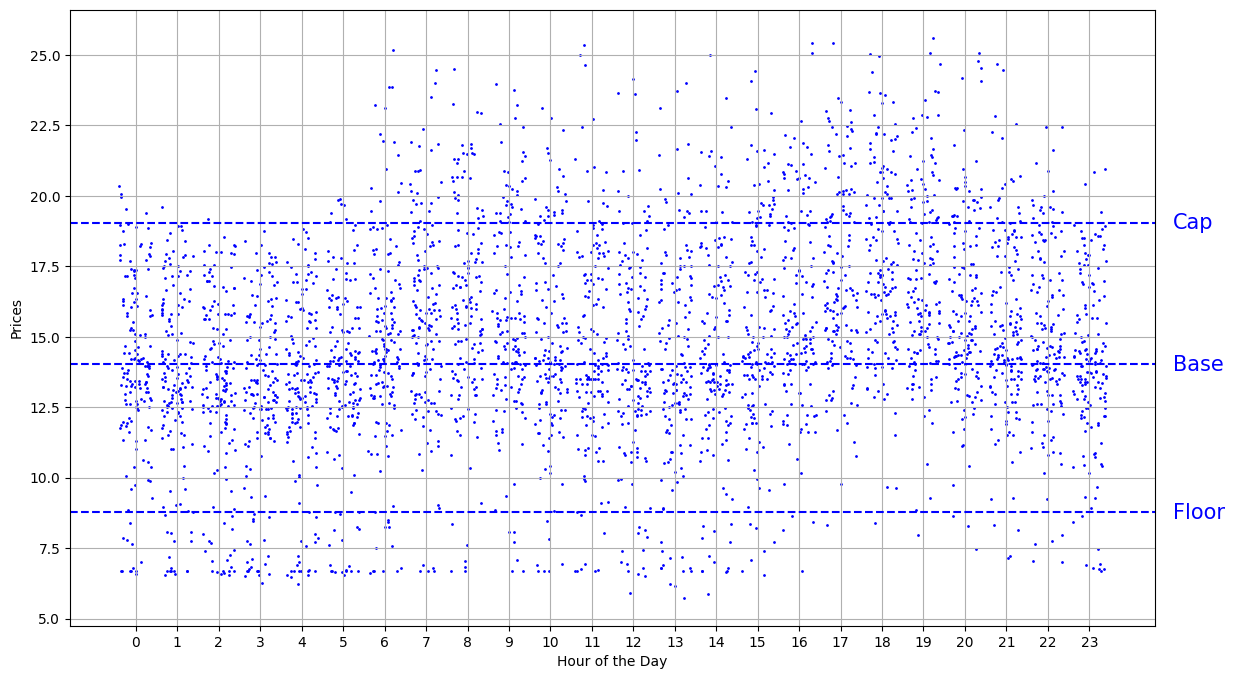

Standard Deviation Summer:  4.9437428004450235 4.181405670946405
Standard Deviation Winter:  6.158974822936303 3.622554164346169


In [2]:
'''
Plotting
'''

summer_ind = summer_series.index
winter_ind = winter_series.index
summer_ind_clean = summer_ind[np.isin(summer.flatten(), summer_clean.flatten())] # array must be 1-D for np.isin()
winter_ind_clean = winter_ind[np.isin(winter.flatten(), winter_clean.flatten())]

def plot_clusters(data_index_lol:list, season):
    plt.figure(figsize=(14, 8))
    for l in range(len(data_index_lol)):
        color = 'blue'
        #day_name = 'weekday' if l == 0 else 'weekend'
        kmeans = KMeans(n_clusters=3, random_state=0).fit(data_index_lol[l][0])
        cluster_centers = kmeans.cluster_centers_
        cluster_centers = np.sort(cluster_centers, axis=0)[::-1]
        print(season + ' ' + '3-Stufen: ', cluster_centers)
        
        datetime_ind = pd.to_datetime(data_index_lol[l][1])
        hours = datetime_ind.hour
        hours_jittered = hours + np.random.uniform(-0.4, 0.4, len(hours))

        plt.scatter(hours_jittered, data_index_lol[l][0].flatten(), color=color, s=1)
        Stufen_names = ['Cap', 'Base', 'Floor']
        for i, Stufe in enumerate(cluster_centers):
            plt.axhline(y=Stufe[0], color=color, linestyle='--', linewidth=1.5)
            plt.text(x=25.02, y=Stufe[0], s=Stufen_names[i], va='center', ha='left', fontsize=15, color=color)
    
    plt.xticks(np.arange(0, 24, 1))
    plt.xlabel('Hour of the Day')
    plt.ylabel('Prices')
    plt.grid(True)
   # plt.savefig('C:/Users/fu/Downloads/Dokumente/Smart Tariffe/TG/Datenanalyse/TG_Datenanalyser/Pictures/price levels/' \
             #   + str(season) + ' 2024 Hourly Prices and Three-Step Tariff Industrie.png',dpi=300, bbox_inches='tight')
    plt.show()


plot_clusters([[summer_clean, summer_ind_clean]], 'summer')
plot_clusters([[winter_clean, winter_ind_clean]], 'winter')
print('Standard Deviation Summer: ', np.std(summer),np.std(summer_clean))
print('Standard Deviation Winter: ', np.std(winter), np.std(winter_clean))